# Perceptron
### Definition
The Perceptron is a classical machine learning classification model foundational to the rest of the machine learning field. It consists of a single neuron with weights and a bias, and a binary output.
Based on the computed z, the binary output is given by the following simple activation function: 
$$
f(z) = \begin{cases}
  1 & \text{if} & z \geq 0 \\
  -1 & \text{if} & z < 0
\end{cases}
$$

Given a set of training data $X$ and training results $y$, with weights $W$ and bias $b$, the perceptron can be trained with the following algorithm:

1. Compute $z=WX+b$
2. Compute $a = f(z)$
3. Let $\hat{y} = a$
4. Adjust weights: $W = W - \eta (y - \hat{y}) X
5. Adjust biases: $b = b - \eta (y - \hat{y})
6. Continue until the maximum number of epochs is reached.

### Advantages
- Works quickly for binary linear classification problems
### Disadvantages
- Limited usefulness outside of specific binary linear classification problems

# Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns

sns.set_theme()

# Pre-Processing
We are going to attempt to classify titanic survivors based on age and fare. My theory is that, the lower in age and the higher in fare the person is, the more likely they are to have survived (as they would have been placed on the lifeboats first).

In [13]:
df = sns.load_dataset('titanic')[["age", "fare", "survived"]]
df = df.dropna(how="any")
df

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0
...,...,...,...
885,39.0,29.1250,0
886,27.0,13.0000,0
887,19.0,30.0000,1
889,26.0,30.0000,1


/nix/store/vdr6qx6rh9mlrxx2caq9870z82991mxv-python3-3.12.13-env/lib/python3.12/site-packages/matplotlib/collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "
/tmp/ipykernel_10422/3807991316.py:7: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 2
  plt.legend(handles=scatter.legend_elements()[0], labels=["Survived", "Died"])
/tmp/ipykernel_10422/3807991316.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=scatter.legend_elements()[0], labels=["Survived", "Died"])


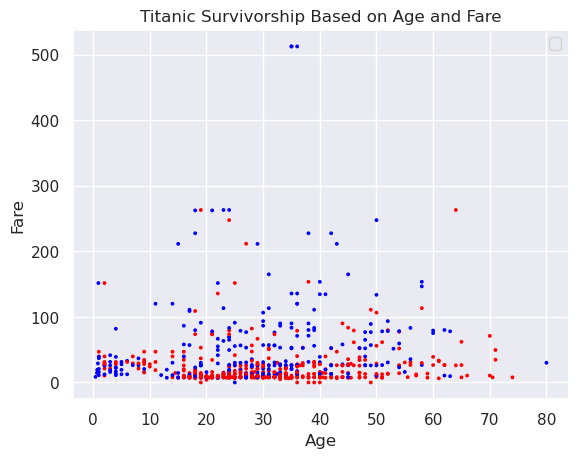

In [14]:
colors = ["Blue" if x == 1 else "Red" for x in df["survived"]]

scatter = plt.scatter(df["age"], df["fare"], c=colors, s = 3)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Titanic Survivorship Based on Age and Fare")
plt.legend(handles=scatter.legend_elements()[0], labels=["Survived", "Died"])
plt.show()

We will continue with the data, as a lower fare seems to indicate a higher chance of death.

Now, we map data to X and y for use in training:

In [15]:
X = df[['age', 'fare']].to_numpy()
y = np.array([-1 if x == 0 else 1 for x in df['survived']])
X

array([[22.    ,  7.25  ],
       [38.    , 71.2833],
       [26.    ,  7.925 ],
       ...,
       [19.    , 30.    ],
       [26.    , 30.    ],
       [32.    ,  7.75  ]], shape=(714, 2))

In [16]:
# Utility function to display the classification line:
def display_classification_line(weights, X, y, bias):
    t = np.linspace(min(X[:, 0]), max(X[:, 0]), 1000)
    y_t = (-weights[0]*t-bias)/weights[1]
    colors = ["Blue" if x == 1 else "Red" for x in y]
    plt.plot(t, y_t)
    plt.scatter(X[:, 0], X[:, 1], c = colors, s = 3)
    plt.show()

In [17]:
# Perceptron class implementation
class Perceptron():
    def __init__(self, _X):
        self.X = _X
        self.dim = np.shape(self.X)[1]
        self.num_elements = np.shape(self.X)[0]
        self.weights = np.random.rand(self.dim, 1)
        self.bias = np.random.rand(1)[0]

    def error(self, y_diff):
        return 1/4 * sum((y_diff[i])**2 for i in range(len(y_diff)))
    
    def predict(self, X):
        z = (self.weights.T @ X.T + self.bias)
        a = np.where(z < 0, -1, z)
        a = np.where(z >= 0, 1, a)
        return a[0]
    
    def update(self, y_diff, eta):
        for i in range(self.num_elements):
            self.weights += -eta * y_diff[i] * self.X[i:i+1, :].T
            self.bias += -eta * y_diff[i]

    def train(self, y_exact, eta = 1/2, epochs = 100):
        errors = []
        for _ in range(epochs):
            y_calc = self.predict(X)
            y_diff = y_calc - y_exact
            errors.append(self.error(y_diff))
            self.update(y_diff, eta)
        return errors

Now, we can train the data with eta = $1/2$:

In [18]:
perc = Perceptron(X)
errors = perc.train(y, eta = 1/2)

Calculate percent correctly classified:

In [19]:
print(str(round((len(X)-errors[-1]) / len(X) * 100, ndigits=2)) + "%")
print(str(int(len(X)-errors[-1])), "correctly classified out of", str(len(X)))

67.51%
482 correctly classified out of 714


Not good, not bad. We will now display the classification line:

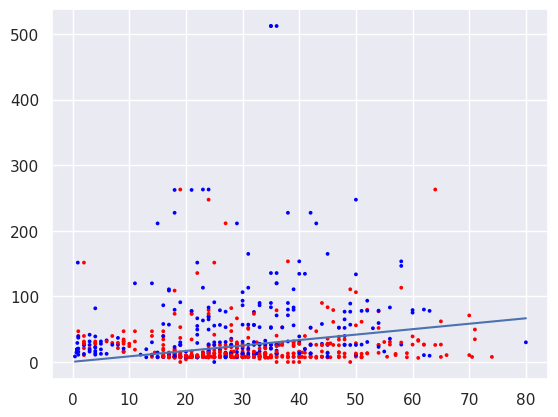

In [20]:
display_classification_line(perc.weights, X, y, perc.bias)

As predicted, the classification line shows that the most likely to survive are the children with high fare, while the most likely to die are the elderly with low fare. There is a strong bias towards fare; most dead travelers had fare $<50$.

Now, we plot error over time (epochs):

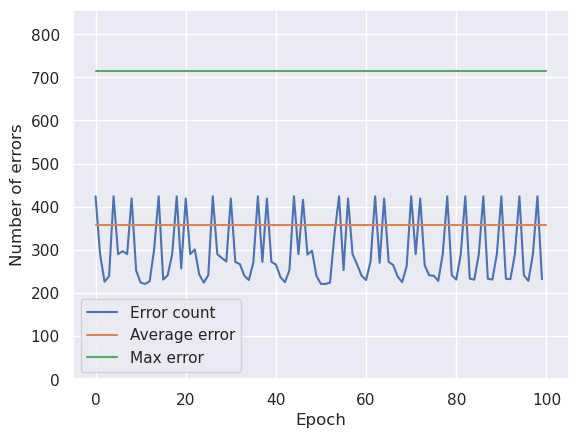

In [21]:
plt.ylim((0.0, len(X)*1.2))
plt.ylabel("Number of errors")
plt.xlabel("Epoch")
plt.plot(errors, label="Error count")
t = np.linspace(0, len(errors), 1000)
plt.plot(t, [len(X)/2 for ti in t], label="Average error")
plt.plot(t, [len(X) for ti in t], label="Max error")
plt.legend()
plt.show()


As seen here, the error oscillates around the average error. Thus, this data is not well modeled by the perceptron.

We will try to nudge the data now

/nix/store/vdr6qx6rh9mlrxx2caq9870z82991mxv-python3-3.12.13-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_10422/3645719864.py:7: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 2
  plt.legend(handles=scatter.legend_elements()[0], labels=["Survived", "Died"])
/tmp/ipykernel_10422/3645719864.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=scatter.legend_elements()[0], labels=["Survived", "Died"])


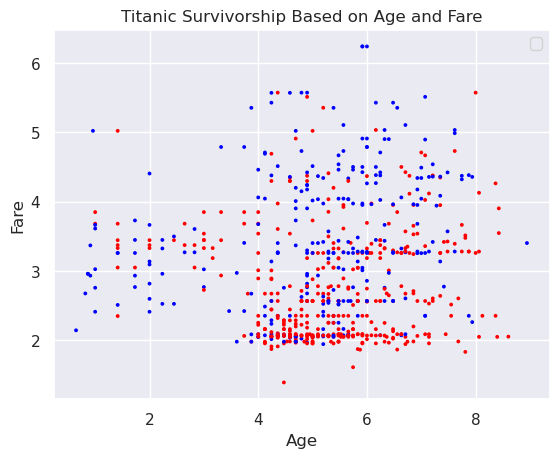

In [60]:
colors = ["Blue" if x == 1 else "Red" for x in df["survived"]]

scatter = plt.scatter(np.sqrt(df["age"]), np.log(df["fare"]), c=colors, s = 3)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Titanic Survivorship Based on Age and Fare")
plt.legend(handles=scatter.legend_elements()[0], labels=["Survived", "Died"])
plt.show()

In [61]:
X = df[['age', 'fare']].to_numpy()
bad_rows = []
for i in range(np.shape(X)[0]):
    if X[i, 1] <= 1e-2:
        bad_rows.append(i)
X = np.delete(X, bad_rows, axis=0)
X[:, 0] = np.sqrt(X[:, 0])
X[:, 1] = np.log(X[:, 1])

y = np.array([-1 if x == 0 else 1 for x in df['survived']])
y = np.delete(y, bad_rows, axis=0)
X

array([[4.69041576, 1.98100147],
       [6.164414  , 4.26666208],
       [5.09901951, 2.07002232],
       ...,
       [4.35889894, 3.40119738],
       [5.09901951, 3.40119738],
       [5.65685425, 2.04769284]], shape=(707, 2))

In [104]:
perc = Perceptron(X)
errors = perc.train(y, eta = 0.5, epochs=100)

In [105]:
print(str(round((len(X)-errors[-1]) / len(X) * 100, ndigits=2)) + "%")
print(str(int(len(X)-errors[-1])), "correctly classified out of", str(len(X)))

67.75%
479 correctly classified out of 707


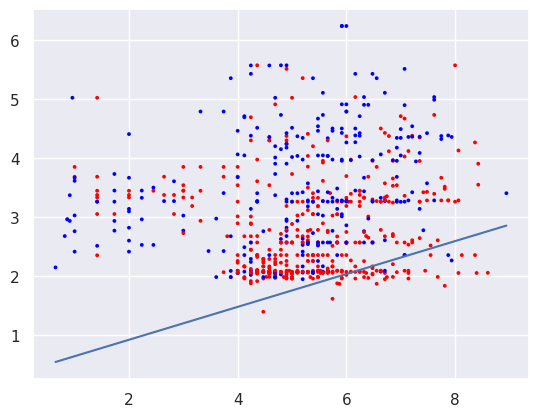

In [106]:
display_classification_line(perc.weights, X, y, perc.bias)